In [2]:
import numpy as np
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
import os
import ipywidgets as widgets
from IPython.display import display

sys.path.append(os.path.abspath('../scripts'))
import ocean_analysis as oa 

Red box lat range: 22.14 to 23.86
Red box lon range: -140.94 to -139.06
Vortex box saving is DEACTIVATED.


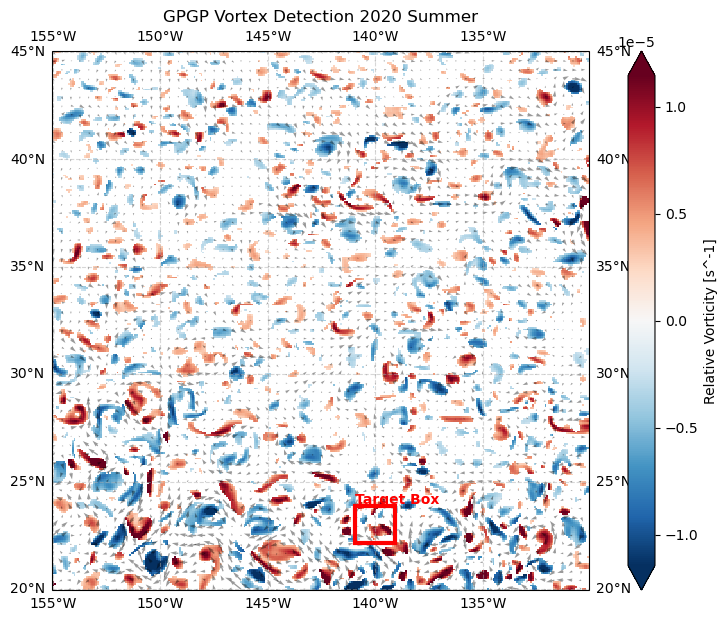

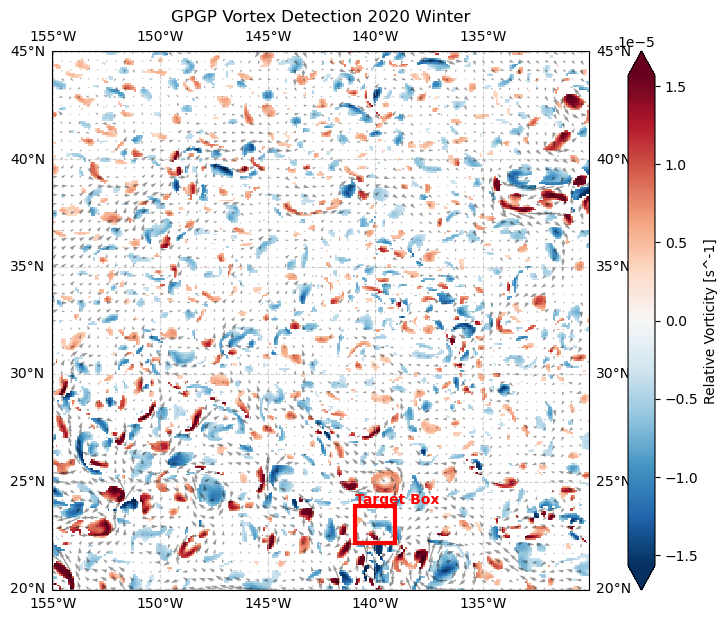

In [3]:
# 1. Load Data

surface_ds_2020 = oa.process_glorys_data('../data/GPGP_aug2020.nc', averaging_period='1D')
surface_ds_2021 = oa.process_glorys_data('../data/GPGP_aug2021.nc', averaging_period='1D')
surface_ds_2022 = oa.process_glorys_data('../data/GPGP_aug2022.nc', averaging_period='1D')
surface_ds_2023 = oa.process_glorys_data('../data/GPGP_aug2023.nc', averaging_period='1D')
surface_ds_2020_winter = oa.process_glorys_data('../data/GPGP_jan2020.nc', averaging_period='1D')
surface_ds_2021_winter = oa.process_glorys_data('../data/GPGP_jan2021.nc', averaging_period='1D')
surface_ds_2022_winter = oa.process_glorys_data('../data/GPGP_jan2022.nc', averaging_period='1D')
surface_ds_2023_winter = oa.process_glorys_data('../data/GPGP_jan2023.nc', averaging_period='1D')


# 2. Compute Metrics

results_2020 = oa.calculate_okubo_weiss(surface_ds_2020)
signed_vort_2020, mask_2020 = oa.get_eddy_intensity(results_2020, alpha=0.2)
results_2020_winter = oa.calculate_okubo_weiss(surface_ds_2020_winter)
signed_vort_2020_winter, mask_2020_winter = oa.get_eddy_intensity(results_2020_winter, alpha=0.2)
# results_2021 = oa.calculate_okubo_weiss(surface_ds_2021)
# signed_vort_2021, ro_intensity_2021, mask_2021 = oa.get_eddy_intensity(results_2021, alpha=0.2)
# results_2022 = oa.calculate_okubo_weiss(surface_ds_2022)
# signed_vort_2022, ro_intensity_2022, mask_2022 = oa.get_eddy_intensity(results_2022, alpha=0.2)
# results_2023 = oa.calculate_okubo_weiss(surface_ds_2023)
# signed_vort_2023, ro_intensity_2023, mask_2023 = oa.get_eddy_intensity(results_2023, alpha=0.2)
# results_2020_winter = oa.calculate_okubo_weiss(surface_ds_2020_winter)
# signed_vort_2020_winter, ro_intensity_2020_winter, mask_2020_winter = oa.get_eddy_intensity(results_2020_winter, alpha=0.2)
# results_2021_winter = oa.calculate_okubo_weiss(surface_ds_2021_winter)
# signed_vort_2021_winter, ro_intensity_2021_winter, mask_2021_winter = oa.get_eddy_intensity(results_2021_winter, alpha=0.2)
# results_2022_winter = oa.calculate_okubo_weiss(surface_ds_2022_winter)
# signed_vort_2022_winter, ro_intensity_2022_winter, mask_2022_winter = oa.get_eddy_intensity(results_2022_winter, alpha=0.2)
# results_2023_winter = oa.calculate_okubo_weiss(surface_ds_2023_winter)
# signed_vort_2023_winter, ro_intensity_2023_winter, mask_2023_winter = oa.get_eddy_intensity(results_2023_winter, alpha=0.2)

    
# 3. SELECT TARGET DOMAIN
# lat_s, lat_n = 25.0, 27.0
# lon_w, lon_e = -145.0, -143.0
# lat_s, lat_n = 22.5, 27.5
# lon_w, lon_e = -145.0, -140.0
# lat_s, lat_n = 20.0, 45.0 # whole GPGP
# lon_w, lon_e = -155.0, -130.0 # whole GPGP
# lat_s, lat_n = 22.5, 27.5
# lon_w, lon_e = -145.0, -140.0
center_lat = 23.0
center_lon = -140.0

dlat = 192 / 111.32          # ≈ 1.725 deg
dlon = 192 / (111.32 * np.cos(np.deg2rad(center_lat)))   # ≈ 1.903 deg

lat_s = center_lat - dlat/2
lat_n = center_lat + dlat/2
lon_w = center_lon - dlon/2
lon_e = center_lon + dlon/2

print(f"Red box lat range: {lat_s:.2f} to {lat_n:.2f}")
print(f"Red box lon range: {lon_w:.2f} to {lon_e:.2f}")


les_box = oa.get_subdomain(lat_min=lat_s, lon_min=lon_w, lat_max=lat_n, lon_max=lon_e)

# Preprocess for Vortex Fitting

oa.preprocess_netcdf(surface_ds_2020, les_box, base_name='GPGP_aug2020', active=False, subtract_mean=True) 

# 4. Visualize with the Red Rectangle
oa.plot_eddy_intensity(signed_vort_2020, u=surface_ds_2020.uo, v=surface_ds_2020.vo, 
                       title="GPGP Vortex Detection 2020 Summer",
                       target_box=les_box)

oa.plot_eddy_intensity(signed_vort_2020_winter, u=surface_ds_2020_winter.uo, v=surface_ds_2020_winter.vo, 
                       title="GPGP Vortex Detection 2020 Winter",
                       target_box=les_box)

# oa.plot_eddy_intensity(signed_vort_2021, u=surface_ds_2021.uo, v=surface_ds_2021.vo, 
#                        title="GPGP Vortex Detection 2021 Summer",
#                        target_box=les_box)

# oa.plot_eddy_intensity(signed_vort_2022, u=surface_ds_2022.uo, v=surface_ds_2022.vo, 
#                        title="GPGP Vortex Detection 2022 Summer",
#                        target_box=les_box)

# oa.plot_eddy_intensity(signed_vort_2023, u=surface_ds_2023.uo, v=surface_ds_2023.vo, 
#                        title="GPGP Vortex Detection 2023 Summer",
#                        target_box=les_box)
# oa.plot_eddy_intensity(signed_vort_2020_winter, u=surface_ds_2020_winter.uo, v=surface_ds_2020_winter.vo, 
#                        title="GPGP Vortex Detection 2020 Winter",
#                        target_box=les_box)
# oa.plot_eddy_intensity(signed_vort_2021_winter, u=surface_ds_2021_winter.uo, v=surface_ds_2021_winter.vo, 
#                        title="GPGP Vortex Detection 2021 Winter",
#                        target_box=les_box)
# oa.plot_eddy_intensity(signed_vort_2022_winter, u=surface_ds_2022_winter.uo, v=surface_ds_2022_winter.vo, 
#                        title="GPGP Vortex Detection 2022 Winter",
#                        target_box=les_box)
# oa.plot_eddy_intensity(signed_vort_2023_winter, u=surface_ds_2023_winter.uo, v=surface_ds_2023_winter.vo, 
#                        title="GPGP Vortex Detection 2023 Winter",
#                           target_box=les_box)

# # 5. Extract statistics strictly inside that box
# box_data = signed_vort.sel(longitude=slice(les_box[0], les_box[1]), 
#                            latitude=slice(les_box[2], les_box[3]))

# print(f"Stats for red box:")
# print(f"Number of eddy core pixels: {int(box_data.notnull().sum())}")

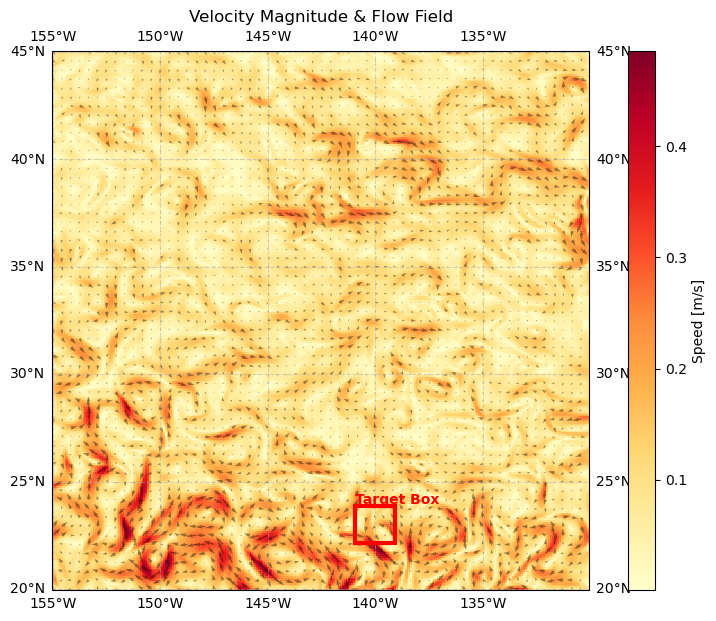

In [4]:
# 6. Plot Velocity Field
oa.plot_ocean_field(
    np.sqrt(surface_ds_2020.uo**2 + surface_ds_2020.vo**2),
    u=surface_ds_2020.uo, v=surface_ds_2020.vo,
    title="Velocity Magnitude & Flow Field",
    cmap='YlOrRd',
    label="Speed [m/s]",
    target_box=les_box,
    vector_scale=15
)

In [ ]:
# time_ranges_2021 = [
#     ('2021-08-01', '2021-08-01'),
#     ('2021-08-02', '2021-08-02'),
#     ('2021-08-03', '2021-08-03'),
#     ('2021-08-04', '2021-08-04'),
#     ('2021-08-05', '2021-08-05'),
#     ('2021-08-06', '2021-08-06'),
#     ('2021-08-07', '2021-08-07'),
#     ('2021-08-08', '2021-08-08'),
#     ('2021-08-09', '2021-08-09'),
#     ('2021-08-10', '2021-08-10'),
#     ('2021-08-11', '2021-08-11'),
#     ('2021-08-12', '2021-08-12'),
#     ('2021-08-13', '2021-08-13'),
#     ('2021-08-14', '2021-08-14'),
#     ('2021-08-15', '2021-08-15'),
#     ('2021-08-16', '2021-08-16'),
#     ('2021-08-17', '2021-08-17'),
#     ('2021-08-18', '2021-08-18'),
#     ('2021-08-19', '2021-08-19'),
#     ('2021-08-20', '2021-08-20'),
#     ('2021-08-21', '2021-08-21'),
#     ('2021-08-22', '2021-08-22'),
#     ('2021-08-23', '2021-08-23'),
#     ('2021-08-24', '2021-08-24'),
#     ('2021-08-25', '2021-08-25'),
#     ('2021-08-26', '2021-08-26'),
#     ('2021-08-27', '2021-08-27'),
#     ('2021-08-28', '2021-08-28'),
#     ('2021-08-29', '2021-08-29'),
#     ('2021-08-30', '2021-08-30'),
#     ('2021-08-31', '2021-08-31')
# ]

# surface_datasets_2021 = []
# ow_results_2021 = []
# signed_vort_2021_list = []
# mask_2021_list = []

# for tr in time_ranges_2021:
#     surface_ds = oa.process_glorys_data(
#         '../data/GPGP_aug2021.nc',
#         averaging_period='1D',
#         time_range=tr
#     )
    
#     results = oa.calculate_okubo_weiss(surface_ds)
#     signed_vort, mask = oa.get_eddy_intensity(results, alpha=0.2)
    
#     surface_datasets_2021.append(surface_ds)
#     ow_results_2021.append(results)
#     signed_vort_2021_list.append(signed_vort)
#     mask_2021_list.append(mask)

# def show_frame(i):
#     oa.plot_eddy_intensity(
#         signed_vort_2021_list[i],
#         u=surface_datasets_2021[i].uo,
#         v=surface_datasets_2021[i].vo,
#         title=f"GPGP Vortex Detection 2021 Summer: {time_ranges_2021[i][0]} to {time_ranges_2021[i][1]}"
#     )

# widgets.interact(
#     show_frame,
#     i=widgets.IntSlider(min=0, max=len(time_ranges_2021)-1, step=1, value=0)
# )

# frames_dir = r"C:\Users\Jelle Gortemaker\Downloads\gif_frames_2021"
# os.makedirs(frames_dir, exist_ok=True)

# for i in range(len(time_ranges_2021)):
#     fig = plt.figure(figsize=(10, 7))
#     ax = plt.axes(projection=ccrs.PlateCarree())

#     ax.add_feature(cfeature.COASTLINE)
#     ax.add_feature(cfeature.LAND, facecolor='lightgray')
#     ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

#     im = signed_vort_2021_list[i].plot(
#         ax=ax,
#         transform=ccrs.PlateCarree(),
#         cmap='RdBu_r',
#         cbar_kwargs={'label': "Relative Vorticity [s^-1]"},
#         center=0,
#         robust=True
#     )

#     skip = 5
#     ax.quiver(
#         surface_datasets_2021[i].uo.longitude[::skip],
#         surface_datasets_2021[i].uo.latitude[::skip],
#         surface_datasets_2021[i].uo[::skip, ::skip],
#         surface_datasets_2021[i].vo[::skip, ::skip],
#         color='black',
#         alpha=0.4,
#         scale=15,
#         transform=ccrs.PlateCarree()
#     )

#     ax.set_title(
#         f"GPGP Vortex Detection 2021 Summer: "
#         f"{time_ranges_2021[i][0]} to {time_ranges_2021[i][1]}"
#     )

#     # Force identical layout for every frame
#     plt.tight_layout()

#     frame_path = os.path.join(frames_dir, f"frame_{i:02d}.png")
#     plt.savefig(frame_path, dpi=150)
#     plt.close(fig)

# print(f"Frames saved in: {frames_dir}")

interactive(children=(IntSlider(value=0, description='i', max=30), Output()), _dom_classes=('widget-interact',…

Frames saved in: C:\Users\Jelle Gortemaker\Downloads\gif_frames_2021
